# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 4. Clustering and annotating celltypes

### Healthy progenitors dataset

This notebook shows the pipeline done on the "Healthy progenitor dataset" (see study for details regarding samples constituting the dataset). Healthy progeniotors are the cells from the healthy dataset that were determined (in Part 2) to be in the G2M or S cell cycle phase and as such are such are understood to be progenitors of the more differentiated cells. I am not providing detailed descriptions of each step here. Those can be found in the notebook for the Healthy dataset. Please refer to the file `Healthy_norm.ipynb`

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np

#### 1. Load data

In [2]:
adata = sc.read('healthy_dr_progen.h5ad')

#### 2. Clustering

In [3]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

In [4]:
sc.tl.leiden(adata, resolution=1.5)

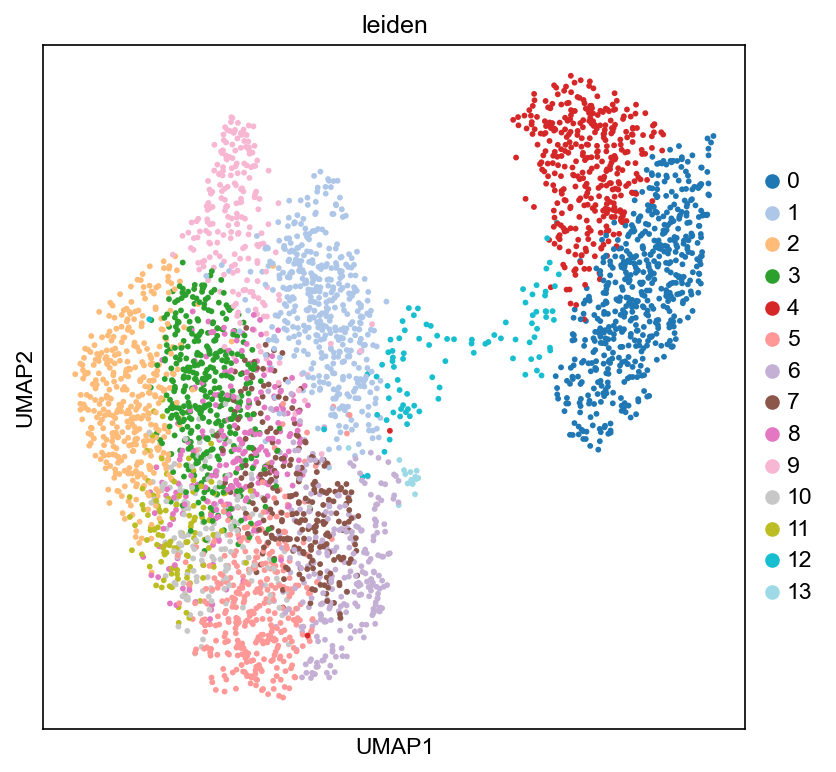

In [5]:
sc.pl.umap(adata, color='leiden', palette='tab20')

In [6]:
sc.tl.leiden(adata, resolution=6, key_added='SubLeiden')

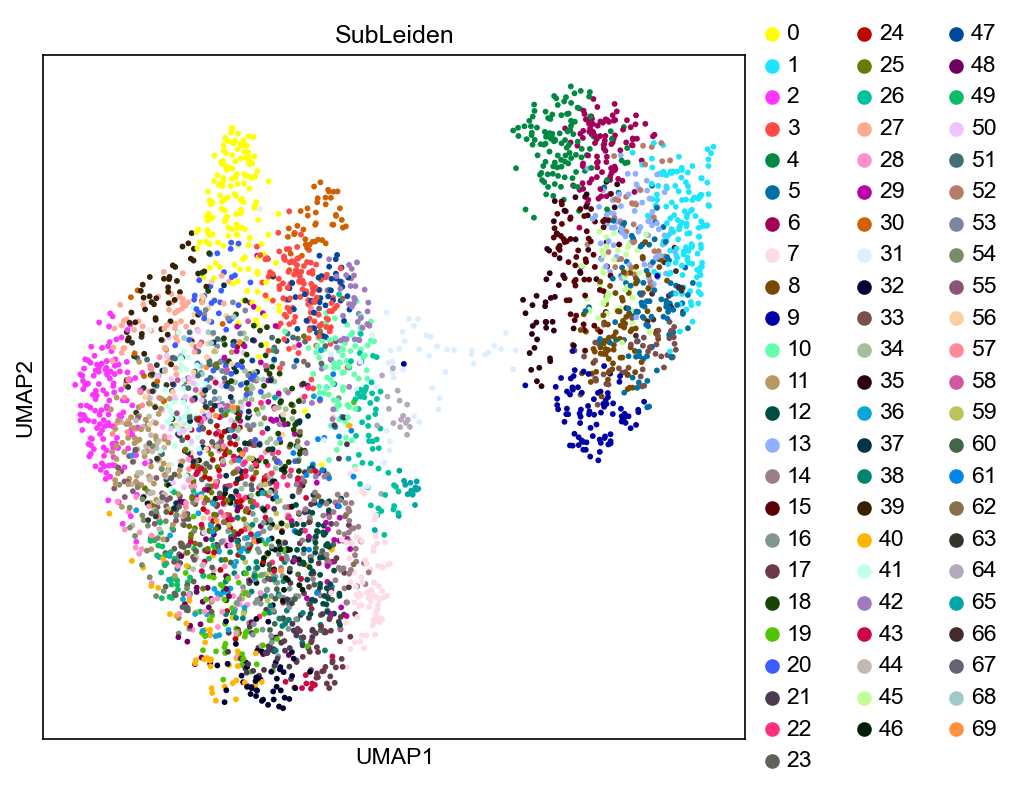

In [7]:
sc.pl.umap(adata, color='SubLeiden')

#### 3. Differential expression and gene markers

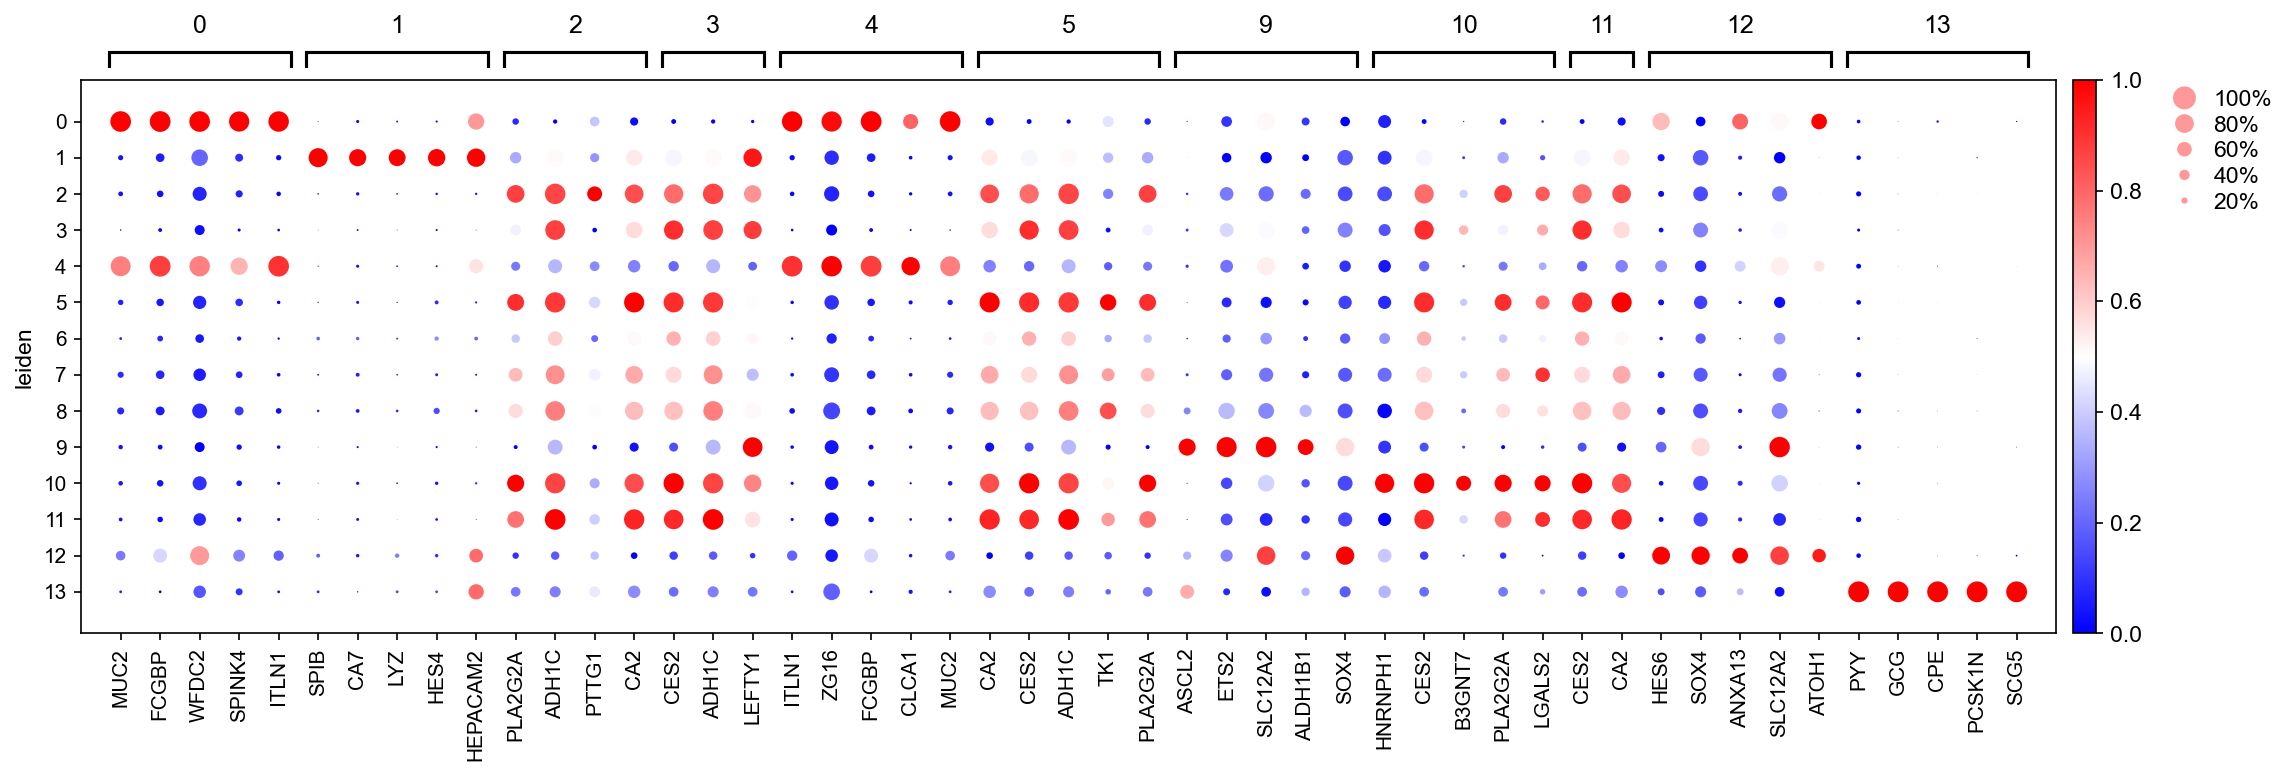

In [8]:
# Rank DEGs per leiden clustering
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
# Filter out genes based on expression specificity and fold changen
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25, 
                               max_out_group_fraction=0.75, min_fold_change=1.5)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key='rank_genes_groups_filtered', 
                                standard_scale='var', color_map='bwr', dendrogram=False)

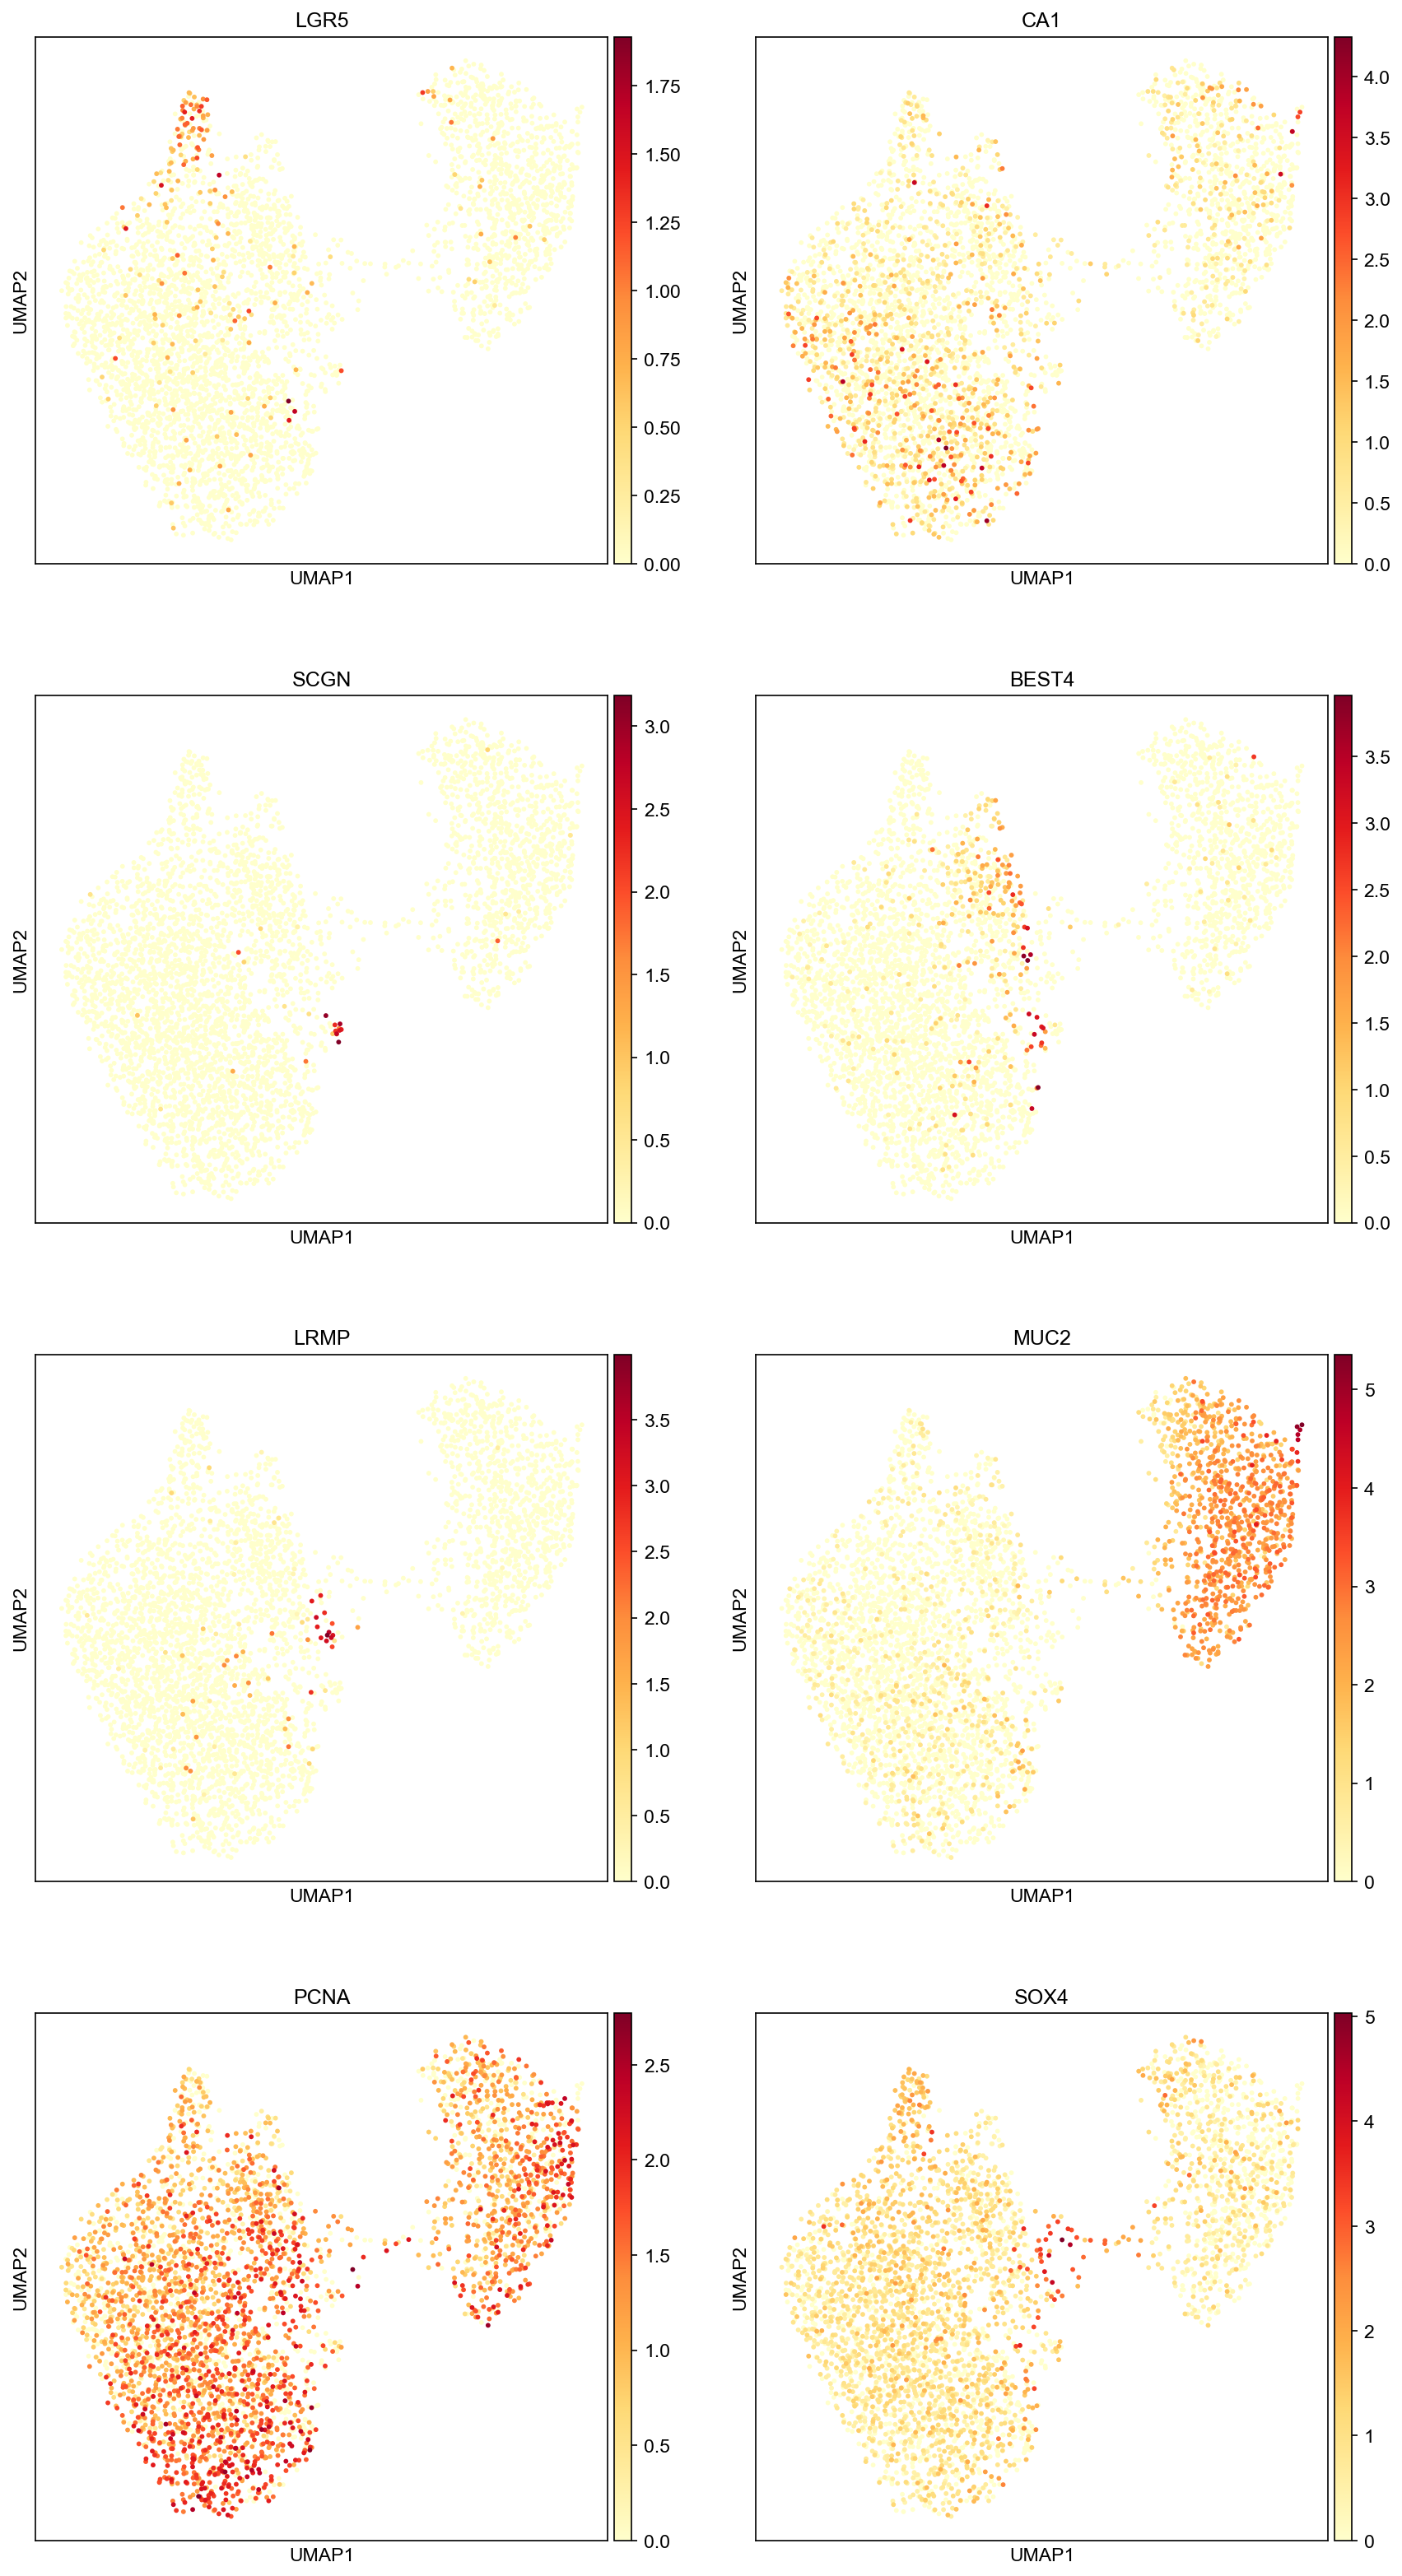

In [9]:
features = ['LGR5', 'CA1', 'SCGN', 'BEST4', 'LRMP', 'MUC2', 'PCNA', 'SOX4']
sc.pl.umap(adata, color=features, use_raw=True, ncols=2, cmap='YlOrRd')

#### 4. Celltype annotation

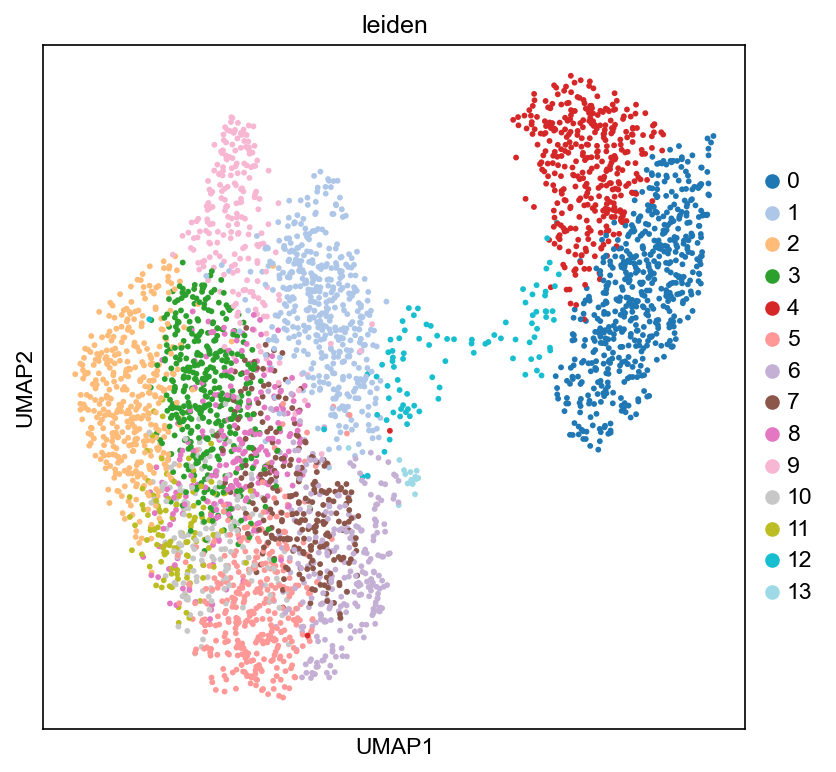

In [10]:
sc.pl.umap(adata, color='leiden', palette='tab20')

In [11]:
sc.tl.leiden(adata, resolution=0.5, restrict_to=('leiden', ['0']))

In [12]:
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden_R', ['12']))

In [13]:
sc.tl.leiden(adata, resolution=0.5, restrict_to=('leiden_R', ['1']))

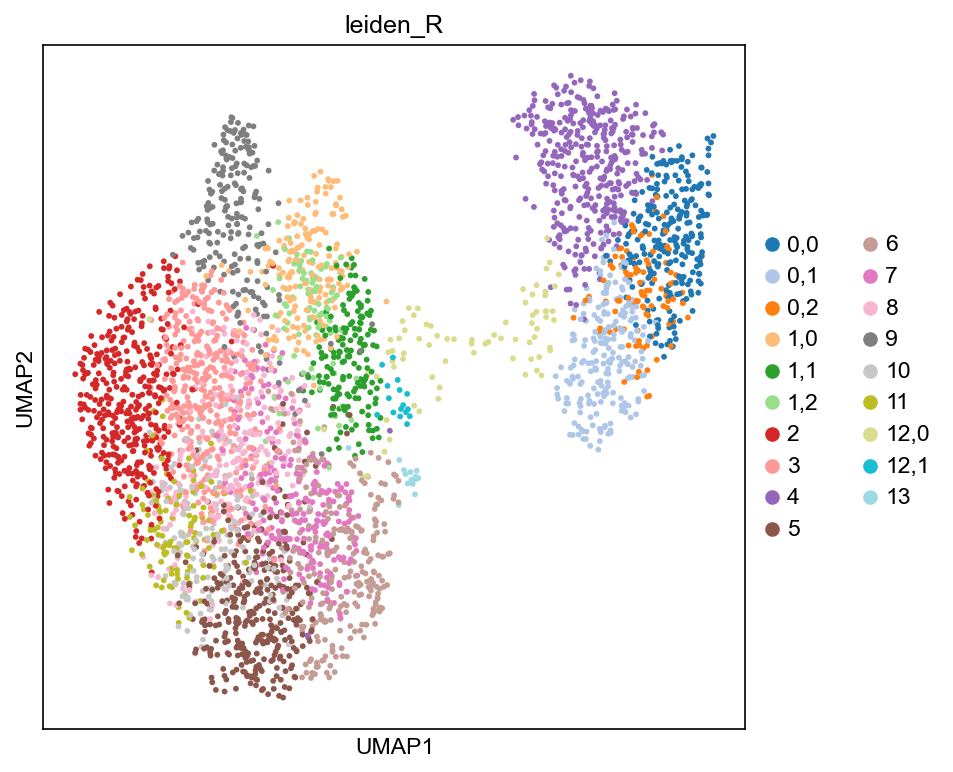

In [14]:
sc.pl.umap(adata, color='leiden_R', palette='tab20')

In [15]:
 adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("0,1", "4")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("0,2", "4")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("3", "2")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("6", "2")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("7", "2")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("8", "2")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("10", "2")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("11", "2")

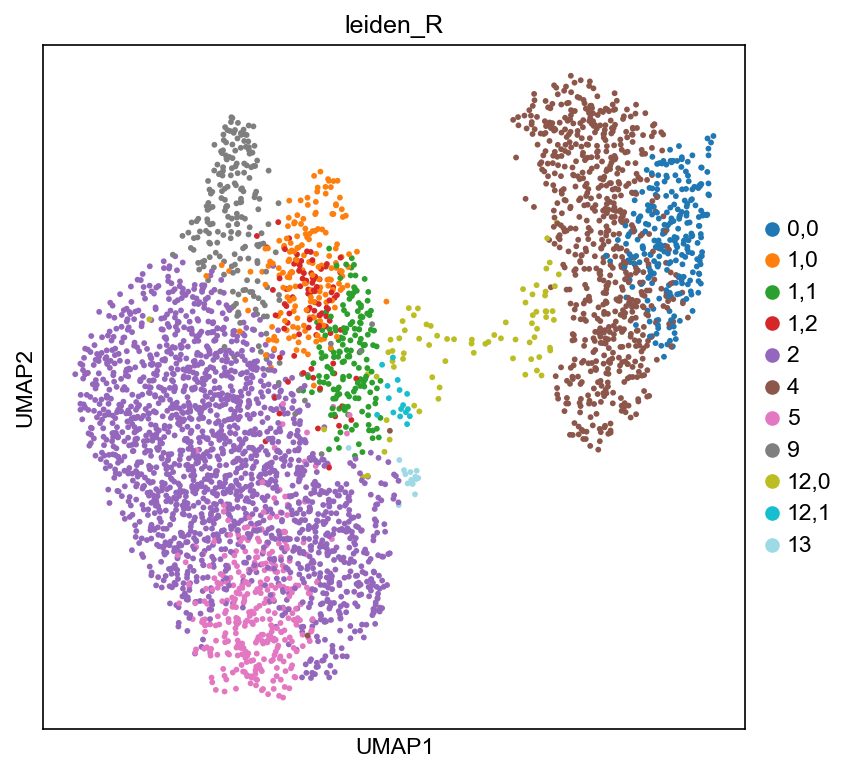

In [16]:
sc.pl.umap(adata, color='leiden_R', palette='tab20')

In [17]:
adata.obs['Celltype'] = adata.obs['leiden_R']
adata.obs['Celltype'] = adata.obs['Celltype'].replace("0,0", "Goblet")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("1,0", "TA BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("1,1", "BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("1,2", "TA BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("2", "TA Colonocytes")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("4", "TA Goblet")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("5", "Colonocytes")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("9", "Stem")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("12,0", "TA SOX4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("12,1", "Tuft")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("13", "EECs")

# Reformat the data as category (necessary for plotting).
adata.obs['Celltype'] = adata.obs['Celltype'].astype('category')
Celltype_order = ['Stem',
                  'TA SOX4+',
                  'TA Colonocytes', 'Colonocytes',
                  'TA BEST4+', 'BEST4+', 
                  'TA Goblet', 'Goblet',                  
                  'EECs' ,'Tuft']
# Explicitly assign custom category order for consistency in plots.
adata.obs['Celltype'].cat.reorder_categories(Celltype_order, inplace=True)

In [18]:
vega_colors = np.array(sc.pl.palettes.vega_20_scanpy)

celltype_colors = np.zeros(len(set(adata.obs['Celltype'])))
celltype_colors = celltype_colors.astype('U7')

celltype_colors[[0]] =  vega_colors[[1]] # Stem color / orange
celltype_colors[[1]] = '#FFCC00' # TA Goblet SOX4+ colors / yellow
celltype_colors[[2, 3]] = vega_colors[[12, 10]]  # Colono colors / pinks
celltype_colors[[4, 5]] = vega_colors[[0, 8]]  # BEST4 colors / blues
celltype_colors[[6, 7]] = vega_colors[[2, 7]]  # Goblet colors / greens
celltype_colors[[8]] = '#E53333'  # EECs / red
celltype_colors[[9]] = '#A9A9A9'  # Tuft / grey

adata.uns['Celltype_colors'] = celltype_colors

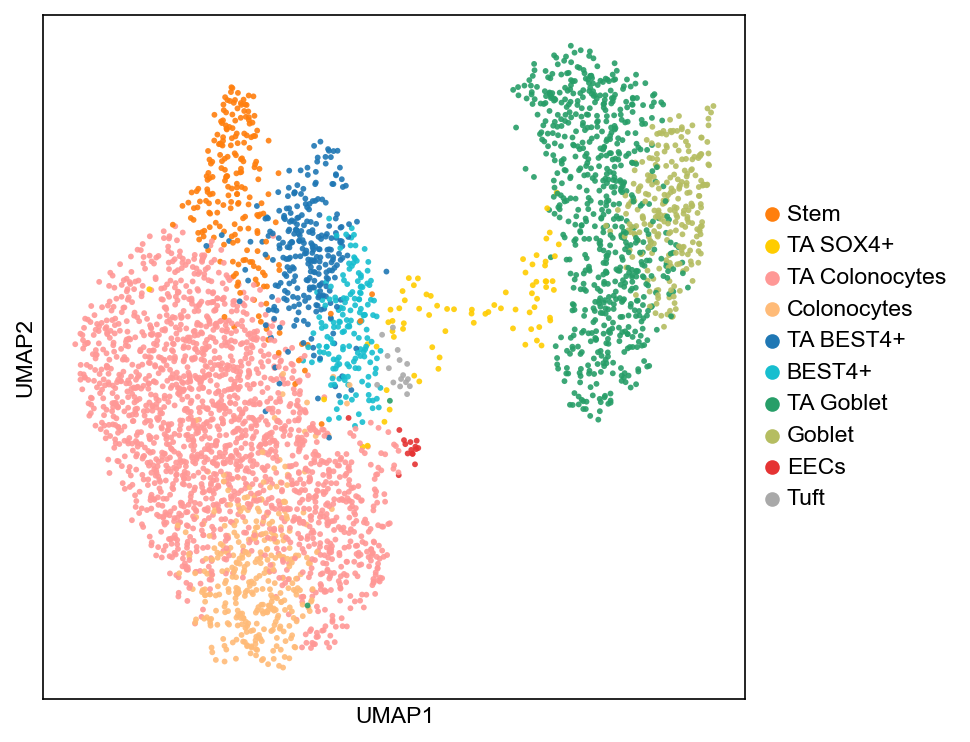

In [19]:
sc.pl.umap(adata, color='Celltype', alpha=0.9, title='')

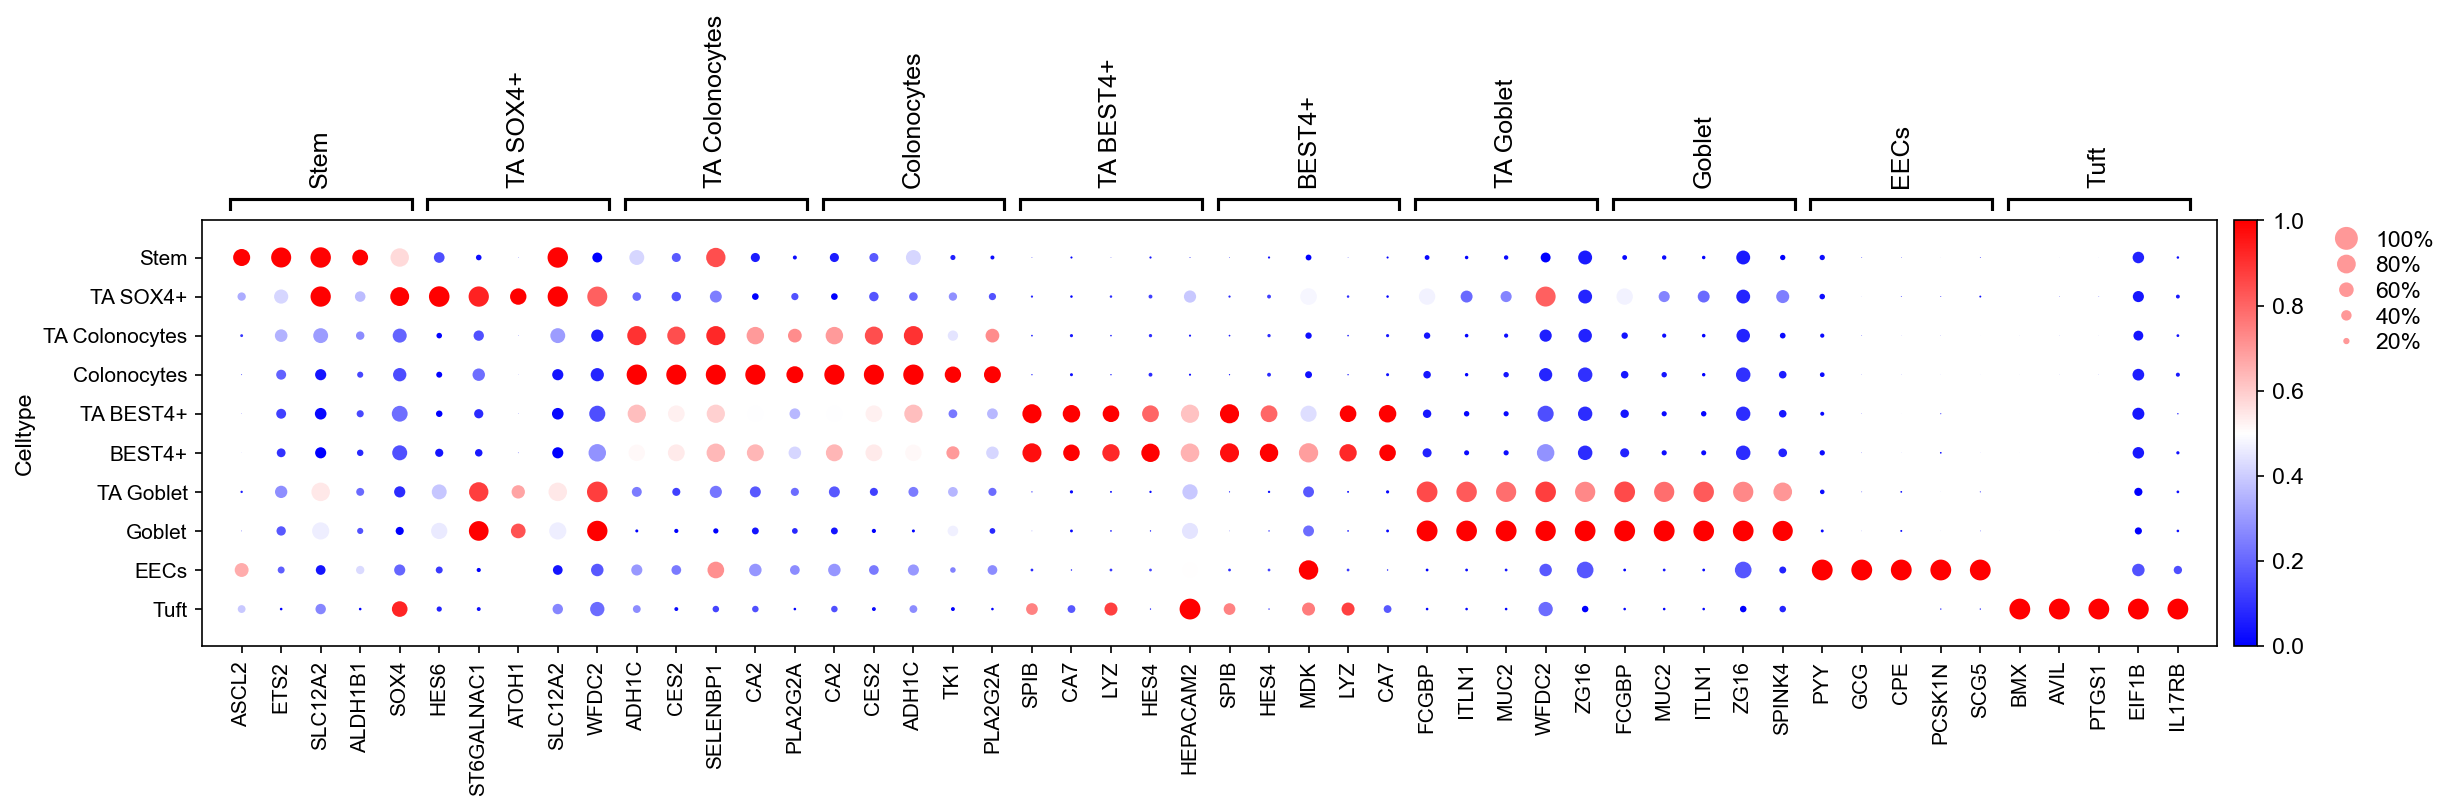

In [20]:
# Rank DEGs per leiden clustering
sc.tl.rank_genes_groups(adata, groupby='Celltype', method='wilcoxon')
# Filter out genes based on expression specificity and fold changen
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25, 
                               max_out_group_fraction=0.75, min_fold_change=1.5)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key='rank_genes_groups_filtered', 
                                standard_scale='var', color_map='bwr', dendrogram=False)

#### 5. Trajectory analysis

In [21]:
sc.tl.paga(adata, groups='Celltype')

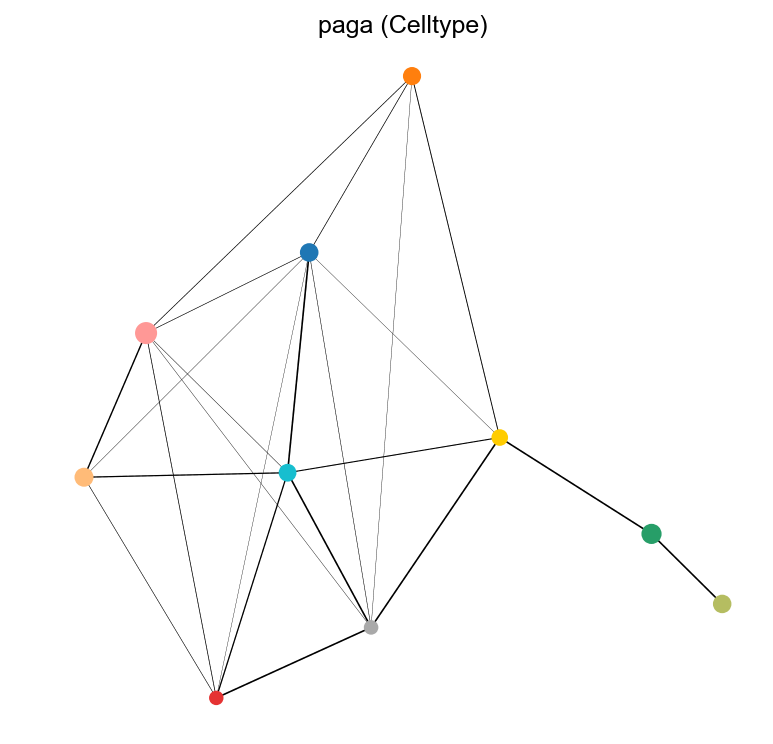

In [22]:
scv.pl.paga(adata, color='Celltype', threshold=0.2, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

In [23]:
adata.obs['SubCelltype'] = adata.obs['Celltype']
for celltype in adata.obs['Celltype'].cat.categories.tolist():
    sc.tl.leiden(adata, resolution=0.4, restrict_to=('SubCelltype', [celltype]), key_added='SubCelltype')

In [24]:
sc.tl.paga(adata, groups='SubCelltype')

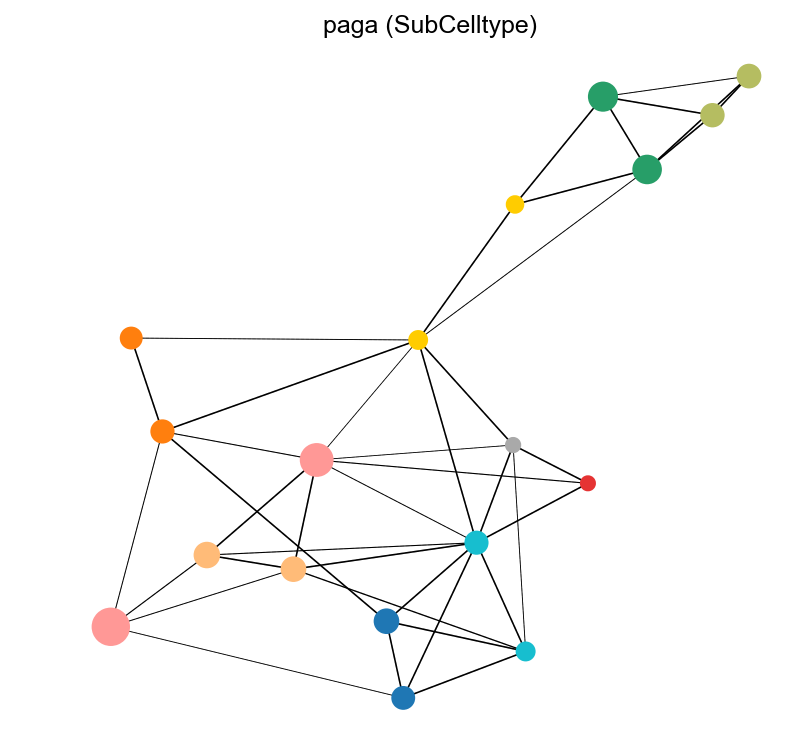

In [25]:
scv.pl.paga(adata, color='Celltype', threshold=0.5, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

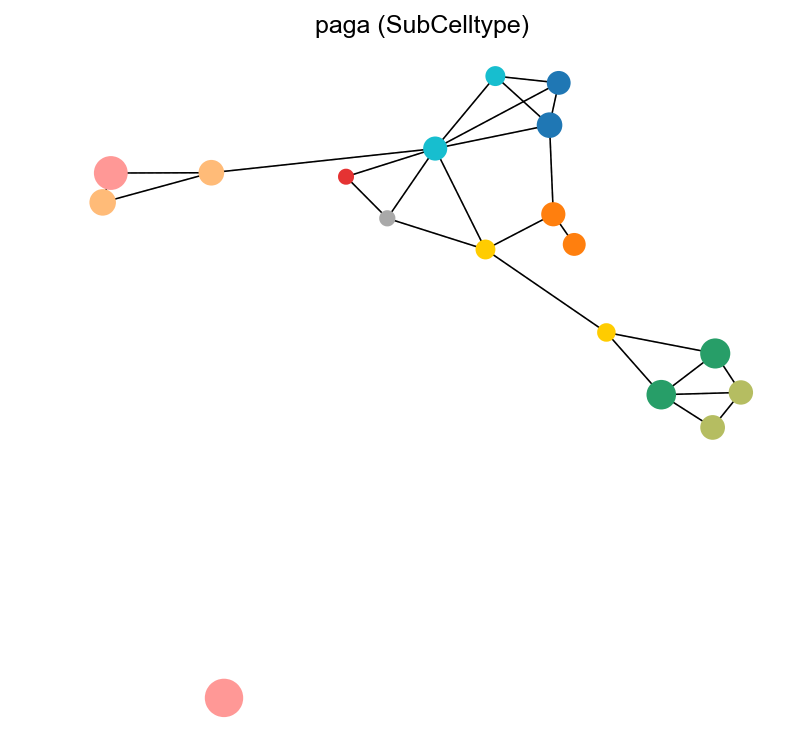

In [26]:
scv.pl.paga(adata, color='Celltype', threshold=1, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

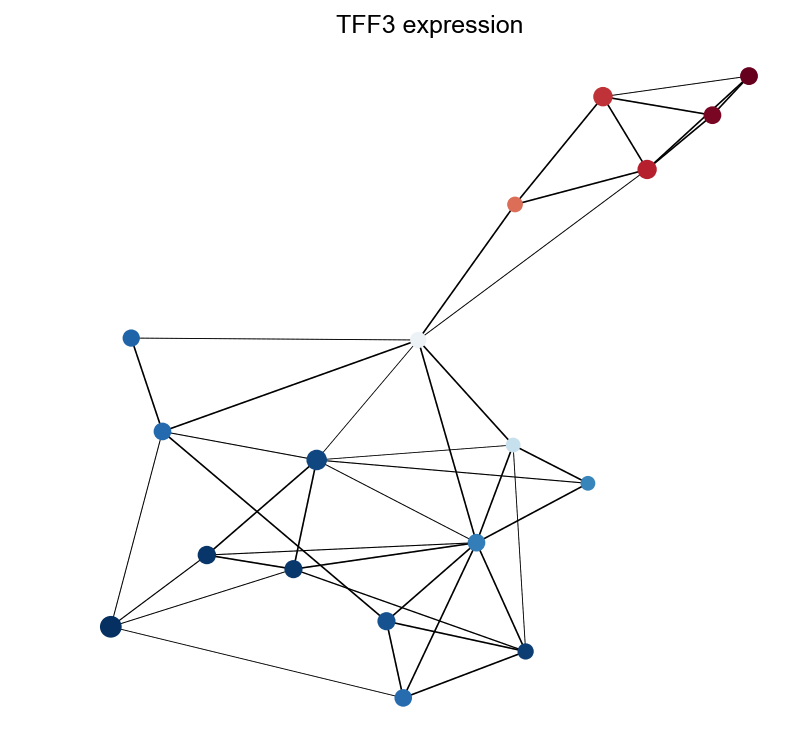

In [27]:
scv.pl.paga(adata, color='TFF3', threshold=0.5, layout='fa', title='TFF3 expression',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

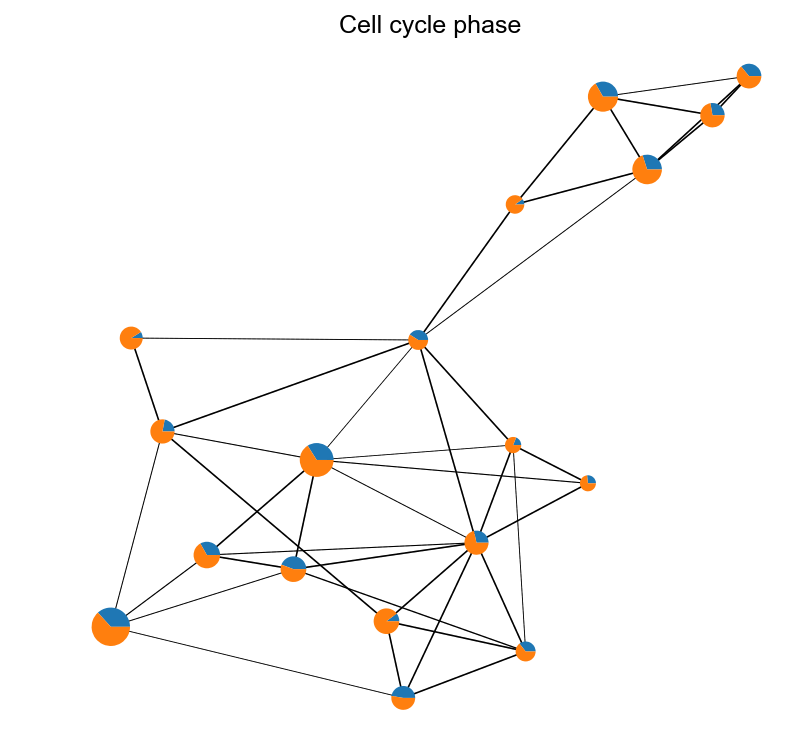

In [28]:
scv.pl.paga(adata, color='phase', threshold=0.5, layout='fa', title='Cell cycle phase',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

#### 6. Graph embedding based on PAGA

In [29]:
sc.tl.draw_graph(adata, init_pos='paga')

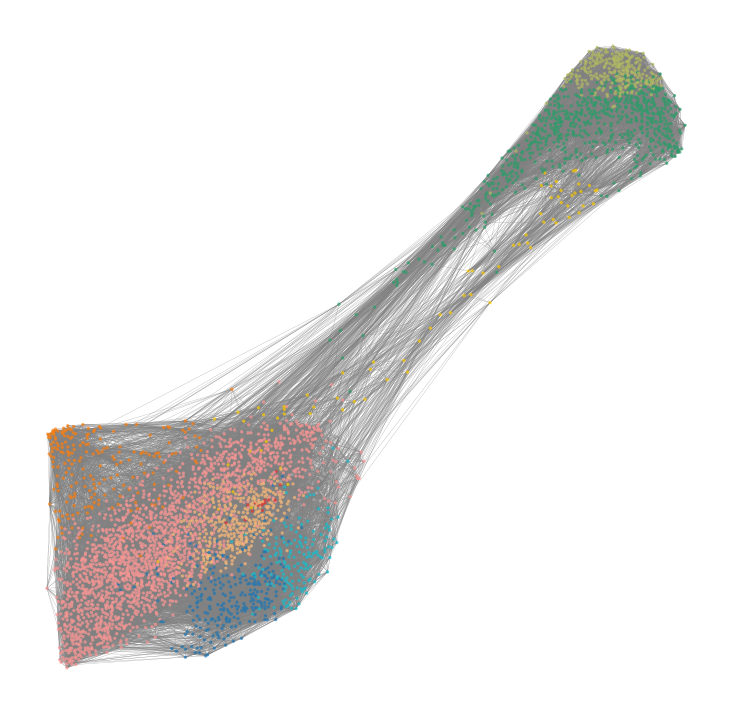

In [30]:
sc.pl.draw_graph(adata, color='Celltype', title='',
                 size=10, alpha=0.7, legend_fontsize=6, frameon=False, edges=True, legend_loc='none')

#### 7. Pseudotime

In [31]:
# Set one of the stem cells as the starting point for the pseudotime.
adata.uns['iroot'] = np.flatnonzero(adata.obs['Celltype']  == 'Stem')[0]

# Calcualte the diffusion map and infer progression of cells through geodesic distance along the graph.
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

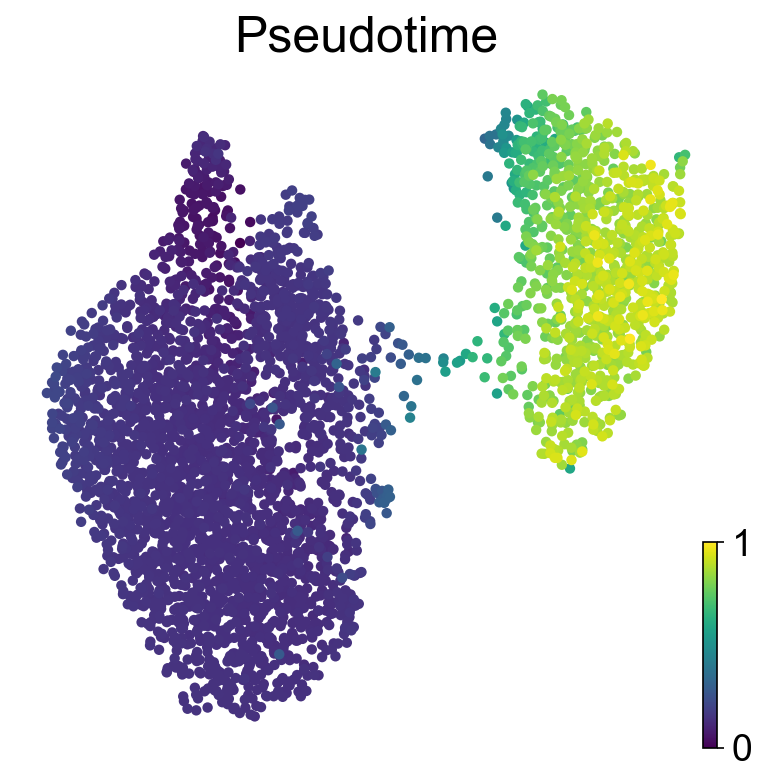

In [32]:
scv.pl.scatter(adata, color='dpt_pseudotime', 
                 size=100, fontsize=24, frameon=False, 
                 cmap='viridis', title='Pseudotime')

#### 8. Save data for the next step 

In [33]:
adata.write("healthy_de_progen.h5ad")